In [1]:
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
corpora = pd.read_parquet("../../corpora/GeneratedCorpus/corpora_v3.parquet")
corpora = corpora.reset_index(names='text_id')


results = pd.DataFrame()
for res in glob("./results/*"):
    temp = pd.read_csv(res)
    temp["model"] = res.split("/")[-1].replace(".csv", "")
    results = pd.concat([results, temp])


df = pd.merge(results, corpora)


# df = df[~df["scenario"].isin(["GRAMMAR SWAP", "GRAMMAR SWAP v2"])]
df = df[df["language"].isin(["INGLÊS", "PB NATIVO"])]

**As análises foram feitas em cima do INGLÊS e PB NATIVO por possuir todas as sentenças**

# Analise das perplexidades e BPB dos modelos

In [3]:
df.groupby(["model"])["ppl"].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Sabia 7B,598.00,20.56,19.09,2.24,9.04,13.06,23.87,147.77
Gemma4-12B,598.00,45.58,68.12,3.50,13.66,21.52,40.31,556.14
Qwen3.5-9B,598.00,50.43,74.58,3.90,15.08,24.21,44.10,550.20
Qwen3.5-9B-it,598.00,58.22,86.05,4.11,16.62,27.40,53.07,656.73
Cabrita,598.00,59.96,81.00,4.39,20.22,32.61,57.48,593.76
Tucano-2b4,598.00,83.15,141.10,2.56,15.87,31.06,64.01,974.30
Tucano-2b4-it,598.00,87.82,151.21,2.67,16.24,32.35,66.82,1077.84
Manaca,598.00,128.52,226.90,3.57,26.89,45.69,89.38,1669.60
Gemma4-12B-it,598.00,803041004.80,4259597204.78,122.86,57088.08,309594.07,5439484.89,42860415586.44


In [4]:
df.groupby(["model"])["bpb"].describe().sort_values(by='mean')


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Gemma4-12B,598.00,1.11,0.33,0.35,0.88,1.03,1.27,2.09
Qwen3.5-9B,598.00,1.14,0.33,0.42,0.90,1.07,1.29,2.13
Qwen3.5-9B-it,598.00,1.18,0.35,0.44,0.92,1.11,1.39,2.16
Sabia 7B,598.00,1.18,0.34,0.31,0.95,1.11,1.36,2.21
Tucano-2b4,598.00,1.25,0.33,0.23,1.02,1.18,1.44,2.22
Tucano-2b4-it,598.00,1.26,0.33,0.24,1.03,1.19,1.46,2.24
Manaca,598.00,1.29,0.32,0.30,1.08,1.23,1.48,2.23
Cabrita,598.00,1.31,0.34,0.48,1.08,1.24,1.47,2.27
Gemma4-12B-it,598.00,4.60,1.39,1.51,3.65,4.33,5.20,9.71


Como o Gemma4 apresentou comportamentos anormais, os resultados dos modelos Instruction-Tuned serão desconsiderados

In [5]:
df = df[~df["model"].isin(["Qwen3.5-9B-it", "Tucano-2b4-it", "Gemma4-12B-it"])]

# Análise dos cenários

In [48]:
df.groupby(["scenario"])["ppl"].describe().sort_values(by='mean')

,count,mean,std,min,25%,50%,75%,max
scenario,,,,,,,,
TRANSLATION,492.00,15.64,8.32,4.10,9.52,13.77,19.64,72.81
PB NATIVO,492.00,21.11,15.50,2.24,10.75,16.87,26.78,119.37
GRAMMAR SWAP v2,492.00,27.90,19.81,4.48,13.54,23.76,36.39,166.54
GRAMMAR SWAP v3,492.00,29.26,19.26,3.16,14.25,24.53,37.97,123.68
GRAMMAR SWAP,144.00,29.83,20.12,3.94,15.83,25.54,40.18,153.55
LEXICAL SWAP,492.00,35.11,27.71,6.82,18.58,27.81,42.88,266.05
PB CORRUPTED,492.00,70.95,65.00,6.58,29.58,51.43,87.74,549.36
PB PERMUTED,492.00,263.13,249.51,6.86,82.92,182.84,346.15,1669.60


TRANSLATION e PB NATIVO esperados possuindo as menores perplexidades
- Presença dos multi-língues é o que pode ter feito a TRANSLATION ficar mais baixa

-------

**GRAMMAR SWAP v3** possui perplexidade média e desvio padrão menor que o **LEXICAL SWAP**
- Em geral, para o inglês, os modelos tendem a entender melhor a gramática

**GRAMMAR SWAP v3** vs **GRAMMAR SWAP v2**
- v2 possui uma menor perplexidade média e desvio padrão próximo
- v2 possui muitos textos que se aproximam mais da gramática do português
    - Termo original: ácido oleico
    - Em inglês: oleic acid
    - GRAMMAR SWAP v2: ácido oleico
    - **GRAMMAR SWAP v3: oleico ácido**
        - Está mais de acordo com o que estamos procurando
------

Conjugações verbais incorretas são mais compreensíveis para o modelo do que alteração na ordem das palavras



# Versões do GRAMMAR SWAP

- **GRAMMAR SWAP**: Versão do Giacomo. Possui muitos textos faltantes
- **GRAMMAR SWAP v2**: Possui muitas falhas nos textos e se distancia do objetivo
- **GRAMMAR SWAP v3**: Feito a partir de frases menores, se aproxima mais do que esperamos

In [7]:
v2 = df[df["scenario"] == "GRAMMAR SWAP v2"].groupby(["model"])["ppl"].describe().sort_values(by="mean")
display(v2)

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Sabia 7B,82.00,10.28,3.50,4.48,7.28,9.85,12.81,23.88
Gemma4-12B,82.00,20.31,10.06,8.07,12.99,18.57,25.62,65.30
Qwen3.5-9B,82.00,21.25,9.56,6.92,13.60,19.74,27.08,48.98
Cabrita,82.00,30.60,13.92,5.13,21.54,28.40,37.26,74.41
Tucano-2b4,82.00,36.66,18.07,6.48,23.94,32.96,45.73,94.07
Manaca,82.00,48.33,26.99,12.82,28.88,41.69,58.12,166.54


In [8]:
v3 = df[df["scenario"] == "GRAMMAR SWAP v3"].groupby(["model"])["ppl"].describe().sort_values(by="mean")
display(v3)


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Sabia 7B,82.00,10.71,3.27,3.16,8.23,10.50,12.57,19.94
Gemma4-12B,82.00,20.79,9.53,3.92,12.83,19.76,26.07,49.41
Qwen3.5-9B,82.00,22.10,9.56,3.90,14.19,21.62,27.49,45.98
Cabrita,82.00,31.71,12.80,6.49,22.25,32.05,38.45,69.88
Tucano-2b4,82.00,39.10,17.01,6.98,25.99,36.60,50.27,91.66
Manaca,82.00,51.19,23.23,9.75,34.82,47.82,63.42,123.68


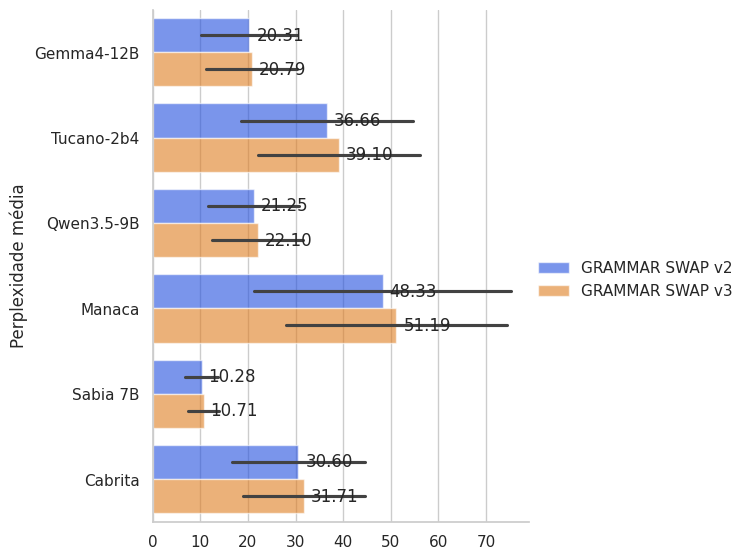

In [9]:
plot_df = df[
    df["scenario"].isin(["GRAMMAR SWAP v2", "GRAMMAR SWAP v3"])
].copy()

g = sns.catplot(
    data=plot_df,
    kind="bar",
    y="model", x="ppl", orient="h", 
    hue="scenario",
    estimator="mean", errorbar="sd", 
    palette="bright", alpha=.6, height=6, 
)

g.set_axis_labels("", "Perplexidade média")
g.legend.set_title("")

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=5)

In [10]:
diff = v3 - v2
display(diff)

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Sabia 7B,0.00,0.43,-0.23,-1.31,0.96,0.65,-0.24,-3.95
Gemma4-12B,0.00,0.48,-0.53,-4.15,-0.17,1.19,0.45,-15.88
Qwen3.5-9B,0.00,0.84,-0.01,-3.03,0.59,1.87,0.41,-3.00
Cabrita,0.00,1.11,-1.12,1.36,0.71,3.65,1.19,-4.53
Tucano-2b4,0.00,2.44,-1.06,0.50,2.05,3.64,4.53,-2.41
Manaca,0.00,2.86,-3.76,-3.08,5.94,6.13,5.30,-42.85


- Textos se comportam da forma esperada -> Menos textos no português nativo -> Perplexidade média mais alta
- A queda no desvio padrão médio pode mostrar que os modelos entendem bem a grmática
    - No v2, muitos textos ainda apresentavam a gramática do português, não do inglês
- Por que os modelos brasileiros também caíram se está afastando ainda mais do PB NATIVO? 

## Análise dos modelos nos diferentes cenários

In [106]:
for metric in ["bpb", "ppl"]:
    models_results = {
        "PB NATIVO": [],
        "TRANSLATION": [],
        "LEXICAL SWAP": [],
        "GRAMMAR SWAP v3": [],
        "PB CORRUPTED": [],
        "PB PERMUTED": [],
    }
    scenarios = list(models_results.keys())
    models_results["model"] = []


    for model in df["model"].unique().tolist():
        models_results["model"].append(model)

        for scenario in scenarios:
            value = df[(df["scenario"] == scenario) & (df["model"] == model)][metric].mean()
            models_results[scenario].append(value)

    models_results_df = pd.DataFrame(models_results)

    # Making "model" the first column
    column_to_move = models_results_df.pop('model')
    models_results_df.insert(0, 'model', column_to_move)

    print(metric.upper())
    display(models_results_df)
    print("\n\n")

BPB


,model,PB NATIVO,TRANSLATION,LEXICAL SWAP,GRAMMAR SWAP v3,PB CORRUPTED,PB PERMUTED
0,Gemma4-12B,0.93,0.82,1.06,0.98,1.33,1.69
1,Tucano-2b4,0.97,1.08,1.32,1.08,1.42,1.82
2,Qwen3.5-9B,0.97,0.84,1.11,1.00,1.37,1.73
3,Manaca,0.99,1.24,1.43,1.12,1.37,1.85
4,Sabia 7B,0.99,0.88,1.16,1.05,1.41,1.79
5,Cabrita,1.13,0.97,1.23,1.20,1.57,1.90





PPL


,model,PB NATIVO,TRANSLATION,LEXICAL SWAP,GRAMMAR SWAP v3,PB CORRUPTED,PB PERMUTED
0,Gemma4-12B,17.00,13.44,32.37,20.79,51.15,171.43
1,Tucano-2b4,24.73,10.54,19.59,39.10,94.60,369.46
2,Qwen3.5-9B,19.51,14.42,39.62,22.10,56.42,187.81
3,Manaca,32.93,24.94,48.51,51.19,131.31,585.13
4,Sabia 7B,9.29,11.68,27.35,10.71,22.93,54.41
5,Cabrita,23.21,18.79,43.21,31.71,69.28,210.55


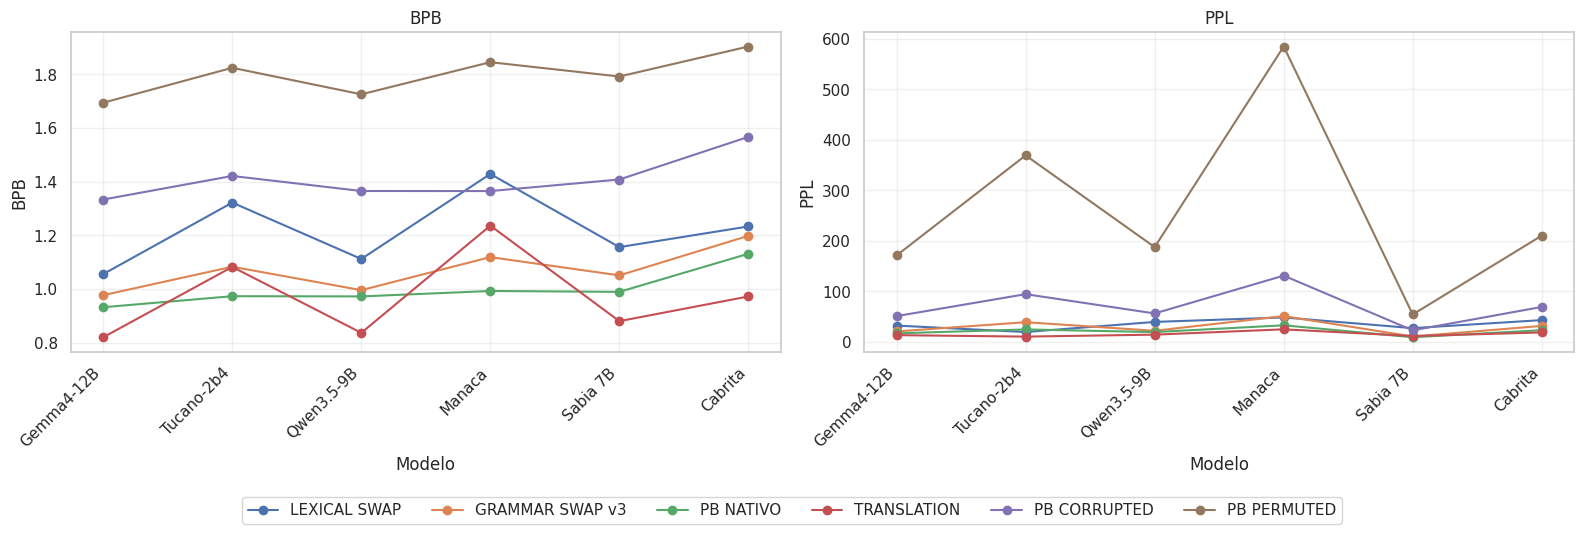

In [55]:
def plot_results(scenarios =["LEXICAL SWAP", "GRAMMAR SWAP v3", "PB NATIVO", "TRANSLATION", "PB CORRUPTED","PB PERMUTED"], confidence_bands = False):

    models = df["model"].unique()
    x = range(len(models))

    metrics = ["bpb", "ppl"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, metric in zip(axes, metrics):

        for scenario in scenarios:
            y = []
            bands = []

            for model in models:
                value = df[(df["scenario"] == scenario) & (df["model"] == model)][metric]
                y.append(value.mean())
                bands.append(value.std())

            y = np.array(y)
            bands = np.array(bands)

            line, = ax.plot(x, y, marker="o", label=scenario)

            # Confidence bands
            if confidence_bands:
                ax.fill_between(x, y-bands, y+bands, alpha=0.2, color=line.get_color())

        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=45, ha="right")
        ax.set_xlabel("Modelo")
        ax.set_ylabel(metric.upper())
        ax.set_title(metric.upper())
        ax.grid(alpha=0.3)


    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=len(scenarios),
        bbox_to_anchor=(0.5, -0.08)
    )

    plt.tight_layout()
    plt.show()

plot_results()

- Os valores de **PERMUTED** mostra que os modelos possuem uma alta surpresa com palavras embaralhadas
- Modelos podem possuir um certo entendimento das regras gramaticais e coerência na ordem das palavras
    - A alta surpresa nos valores indica isso
- O Sabiá é a excessão, com uma perplexidade mais proxima dos outros cenários
    - 54,41. O mais baixo de todos
- No BPB, essa diferença é menos discrepante
    - Mas todos os outros valores são mais próximos
- Como a PPL varia muito e o BPB permanece mais estável, pode-se inferir que a tokenização tem um grande papel nesses resultados

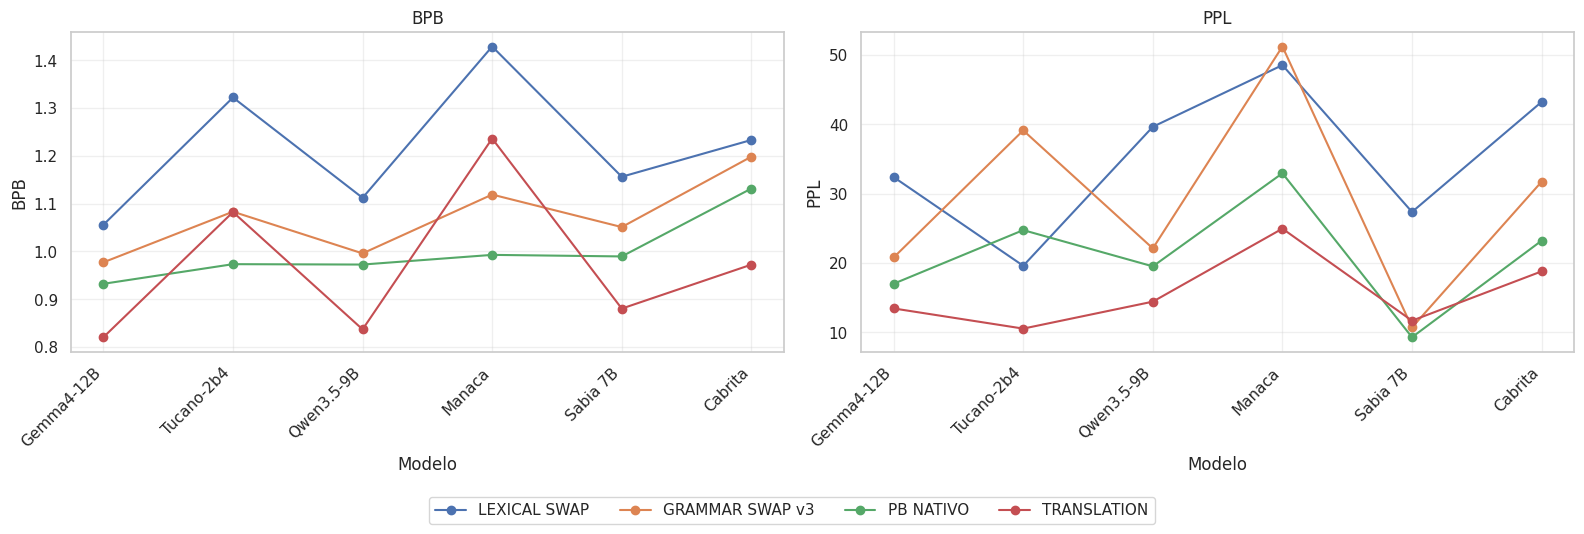

In [59]:
plot_results(scenarios =["LEXICAL SWAP", "GRAMMAR SWAP v3", "PB NATIVO", "TRANSLATION"])

Os modelos parecem preferir textos em inglês do que em português, até mesmo os focados em português. POR QUÊ?

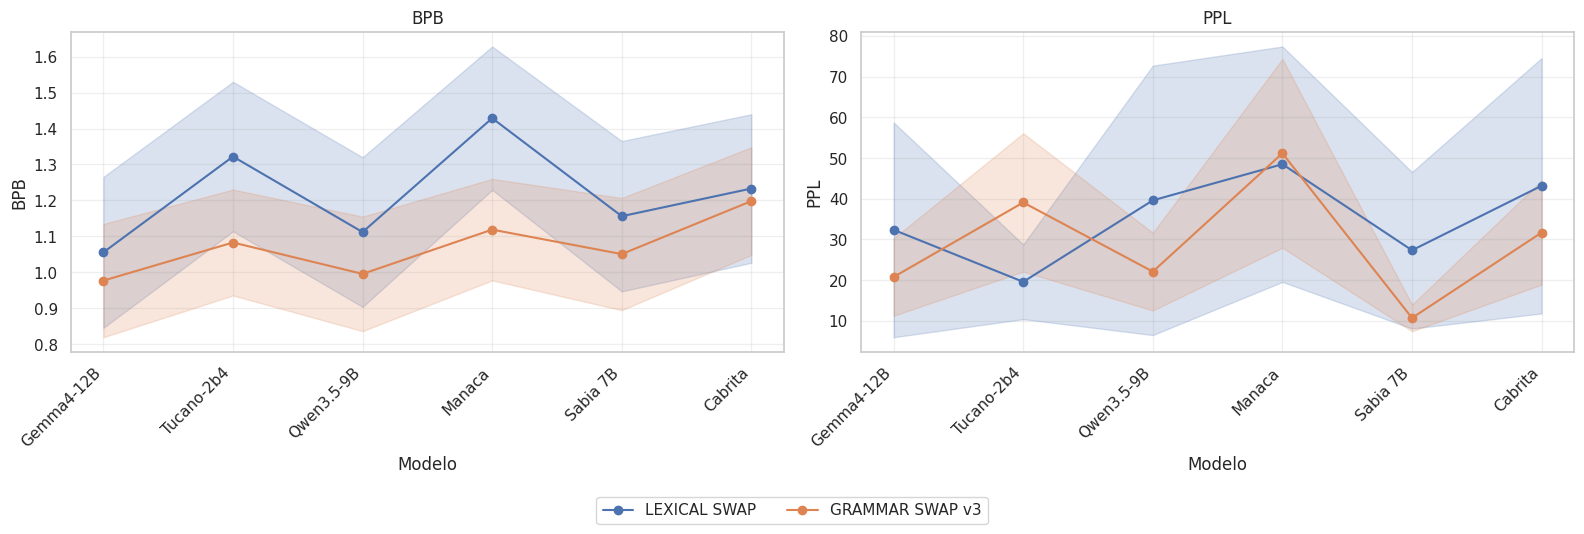

In [58]:
plot_results(scenarios =["LEXICAL SWAP", "GRAMMAR SWAP v3"], confidence_bands=True)

- Para o BPB, o GRAMMAR SWAP é sempre mais natural para o modelo do que na PPL (Isso nas médias absolutas dos resultados)
- No BPB, o GRAMMAR SWAP segue um comportamento muito parecido com o PB NATIVO
    - O modelo teria um entendimento maior das características superficiais da língua (sistema de escrita), porque é isso que se mantém constante

# BPB and PPL in GRAMMAR vs LEXICAL SWAP

In [104]:
def plot_grammar_and_lexical_swap(model, plot=True):

    print(model)

    metrics = ["bpb", "ppl"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, metric in zip(axes, metrics):

        GS = df[(df["scenario"]=="GRAMMAR SWAP v3") & (df["model"]==model)][metric].to_list()
        LS = df[(df["scenario"]=="LEXICAL SWAP") & (df["model"]==model)][metric].to_list()

        cont = 0
        for gs, ls in zip(GS, LS):
            if gs < ls:
                cont += 1

        perc = cont / len(GS) * 100
        print(f"GRAMMAR SWAP's {metric.upper()} < LEXICAL SWAP in {perc:.2f}% of the times")

        x = range(len(GS))

        ax.plot(x, GS, label="GRAMMAR SWAP")
        ax.plot(x, LS, label="LEXICAL SWAP")
        ax.legend()
        ax.set_title(metric.upper())

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=len(scenarios),
        bbox_to_anchor=(0.5, -0.08)
    )

    plt.tight_layout()
    plt.show()


Gemma4-12B
GRAMMAR SWAP's BPB < LEXICAL SWAP in 56.10% of the times
GRAMMAR SWAP's PPL < LEXICAL SWAP in 63.41% of the times


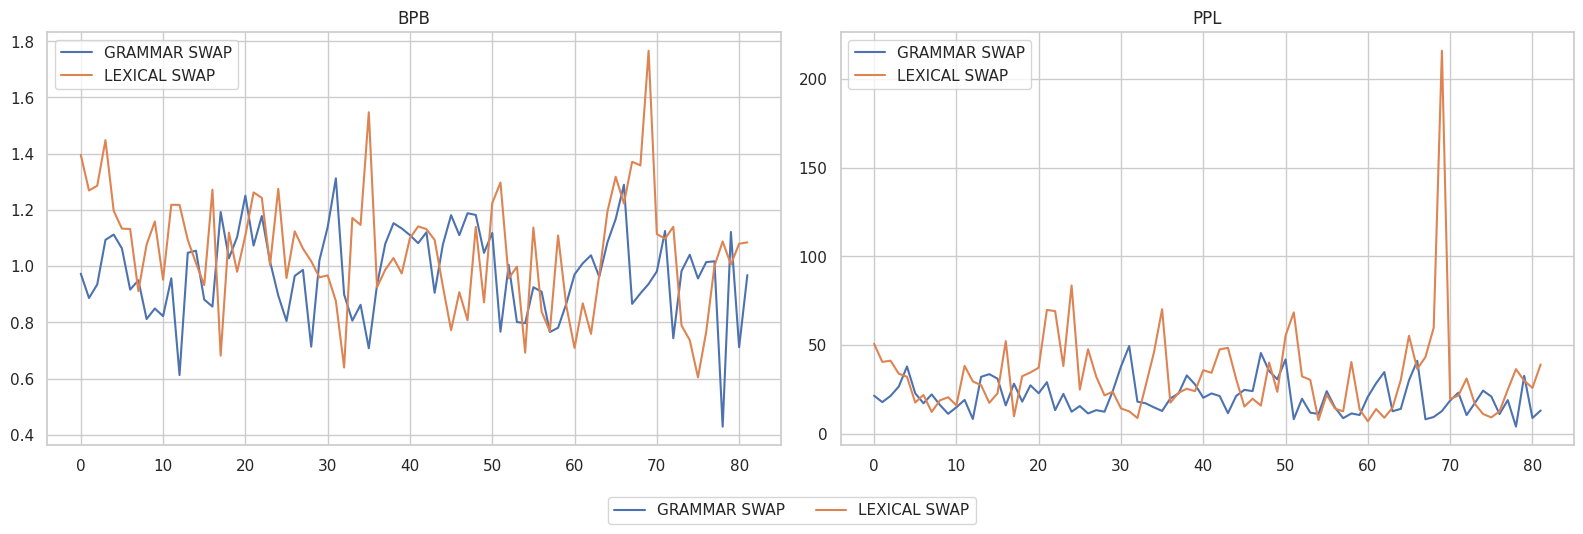

Tucano-2b4
GRAMMAR SWAP's BPB < LEXICAL SWAP in 81.71% of the times
GRAMMAR SWAP's PPL < LEXICAL SWAP in 15.85% of the times


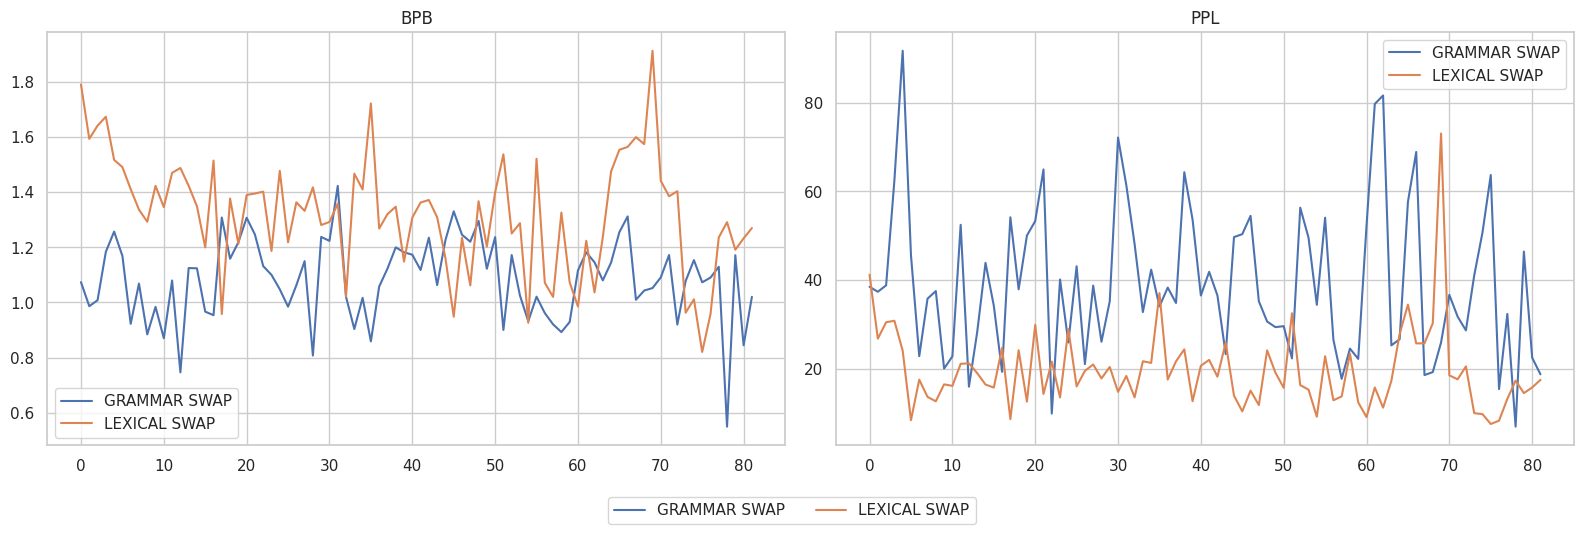

Qwen3.5-9B
GRAMMAR SWAP's BPB < LEXICAL SWAP in 62.20% of the times
GRAMMAR SWAP's PPL < LEXICAL SWAP in 68.29% of the times


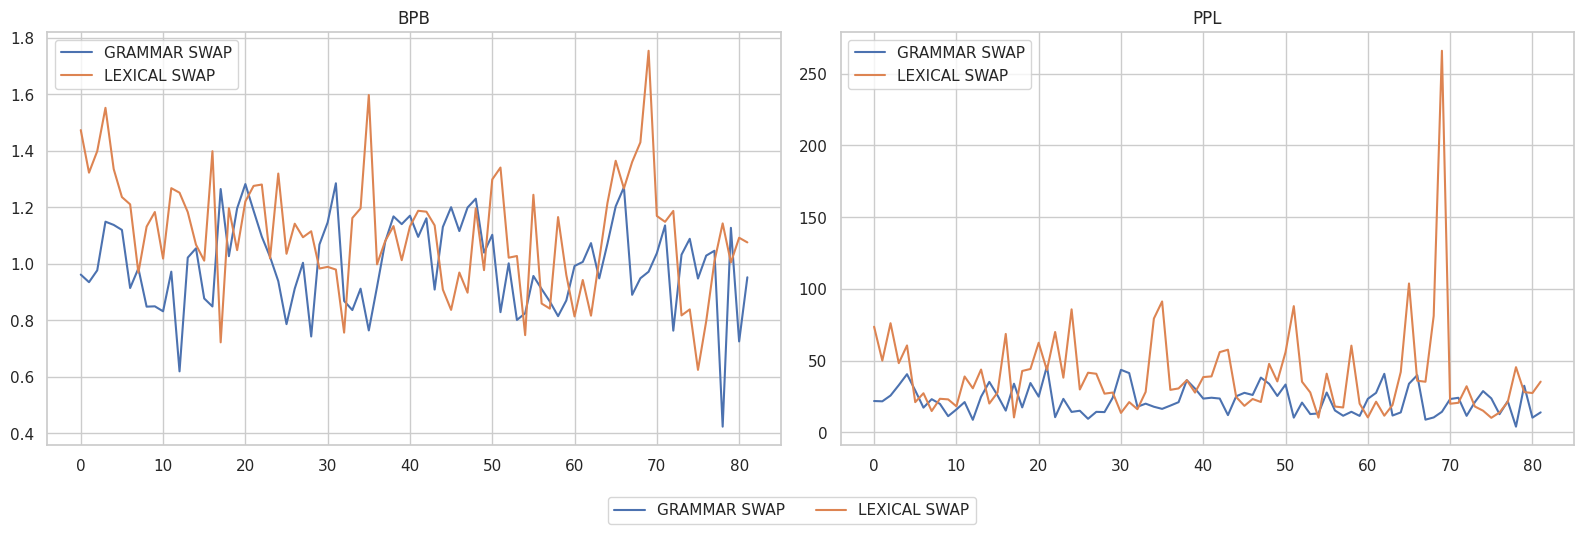

Manaca
GRAMMAR SWAP's BPB < LEXICAL SWAP in 91.46% of the times
GRAMMAR SWAP's PPL < LEXICAL SWAP in 45.12% of the times


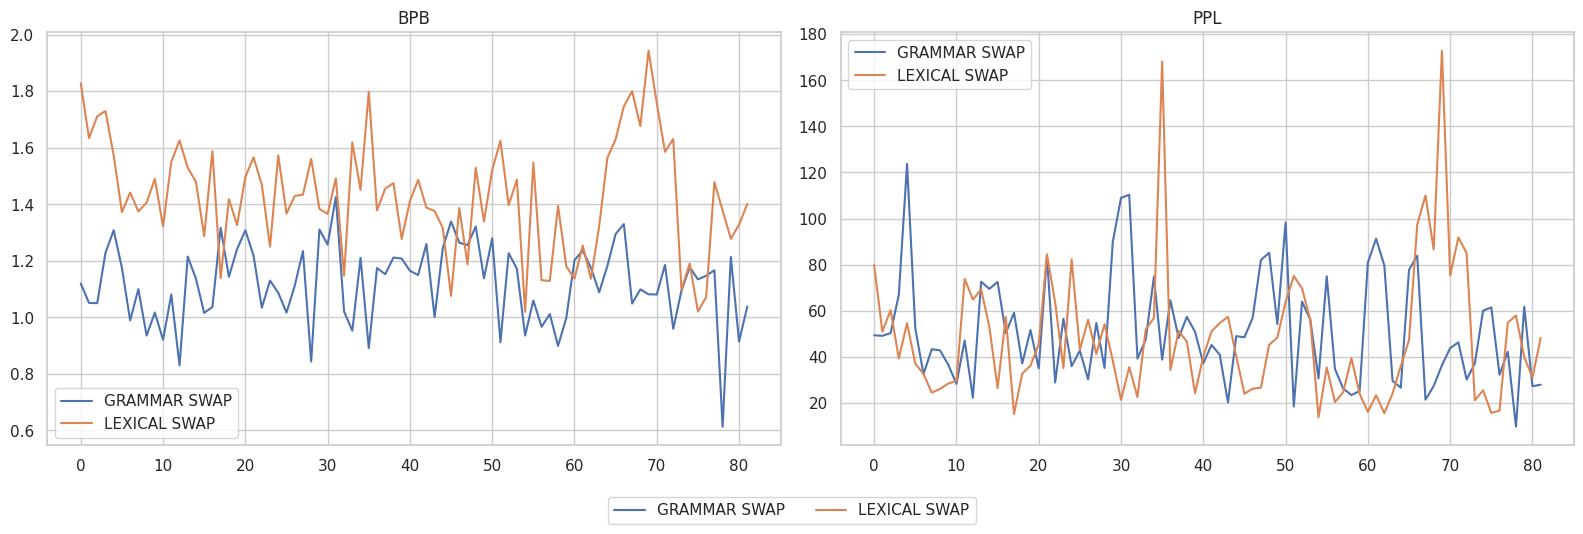

Sabia 7B
GRAMMAR SWAP's BPB < LEXICAL SWAP in 60.98% of the times
GRAMMAR SWAP's PPL < LEXICAL SWAP in 87.80% of the times


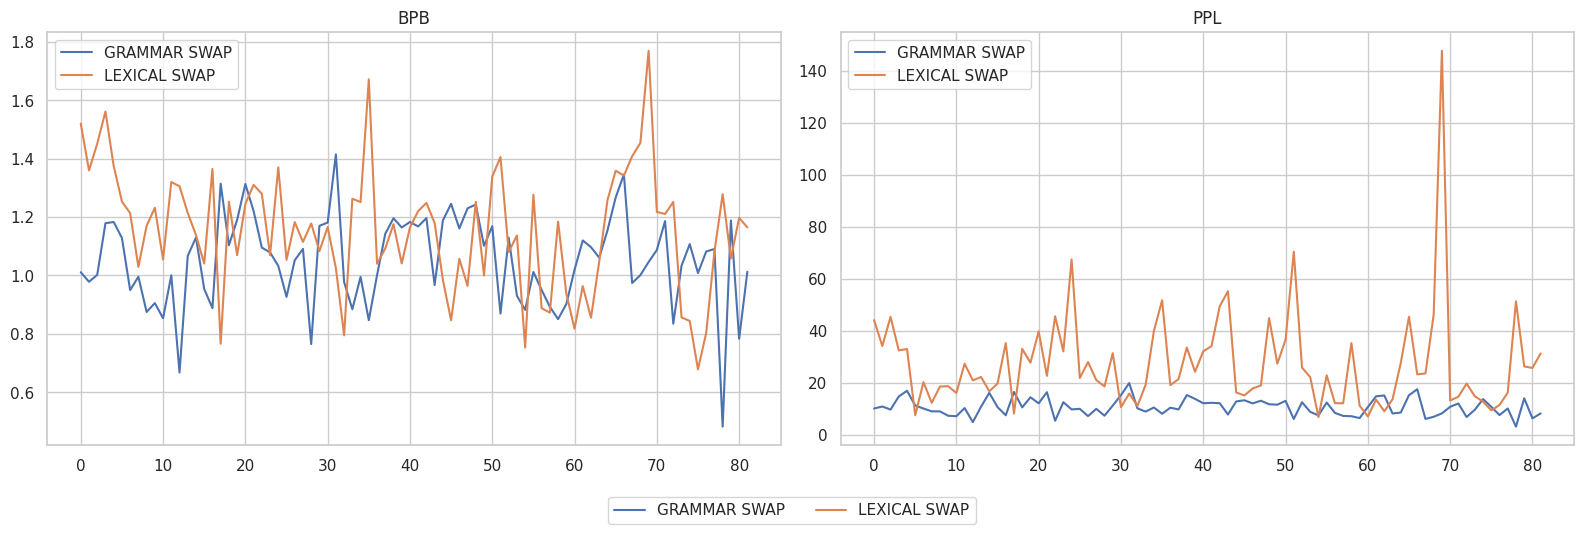

Cabrita
GRAMMAR SWAP's BPB < LEXICAL SWAP in 54.88% of the times
GRAMMAR SWAP's PPL < LEXICAL SWAP in 63.41% of the times


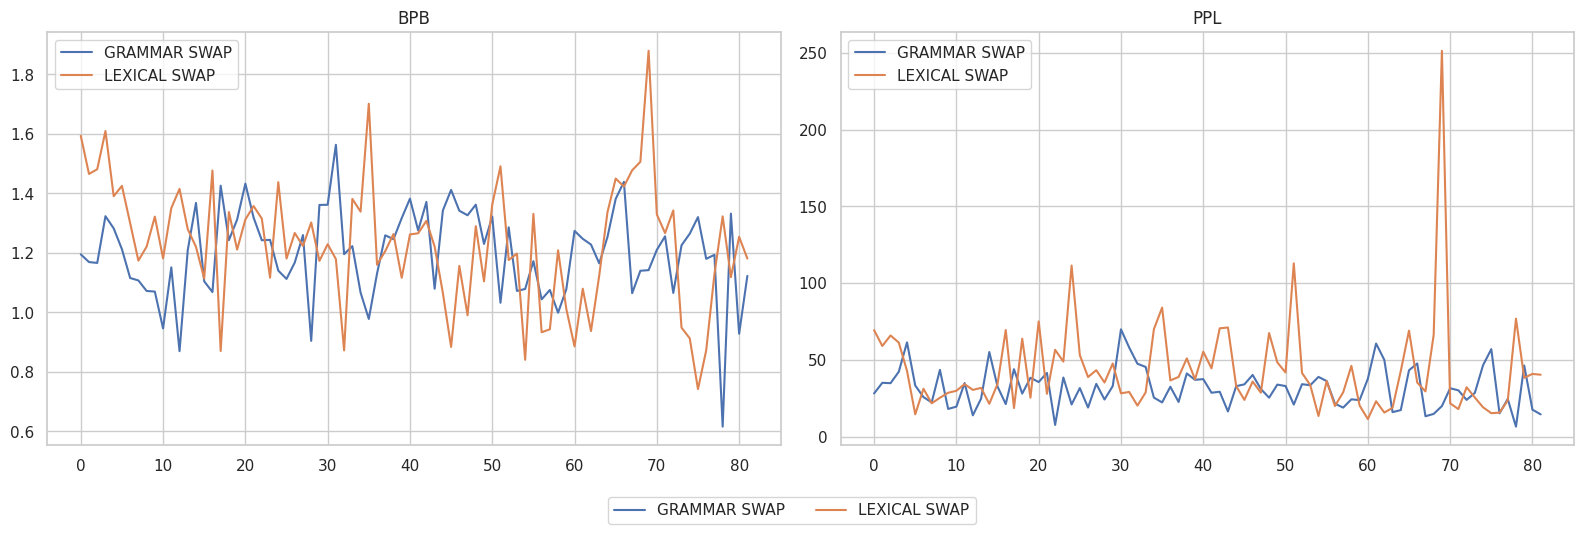

In [105]:
for model in df["model"].unique():
    plot_grammar_and_lexical_swap(model, False)

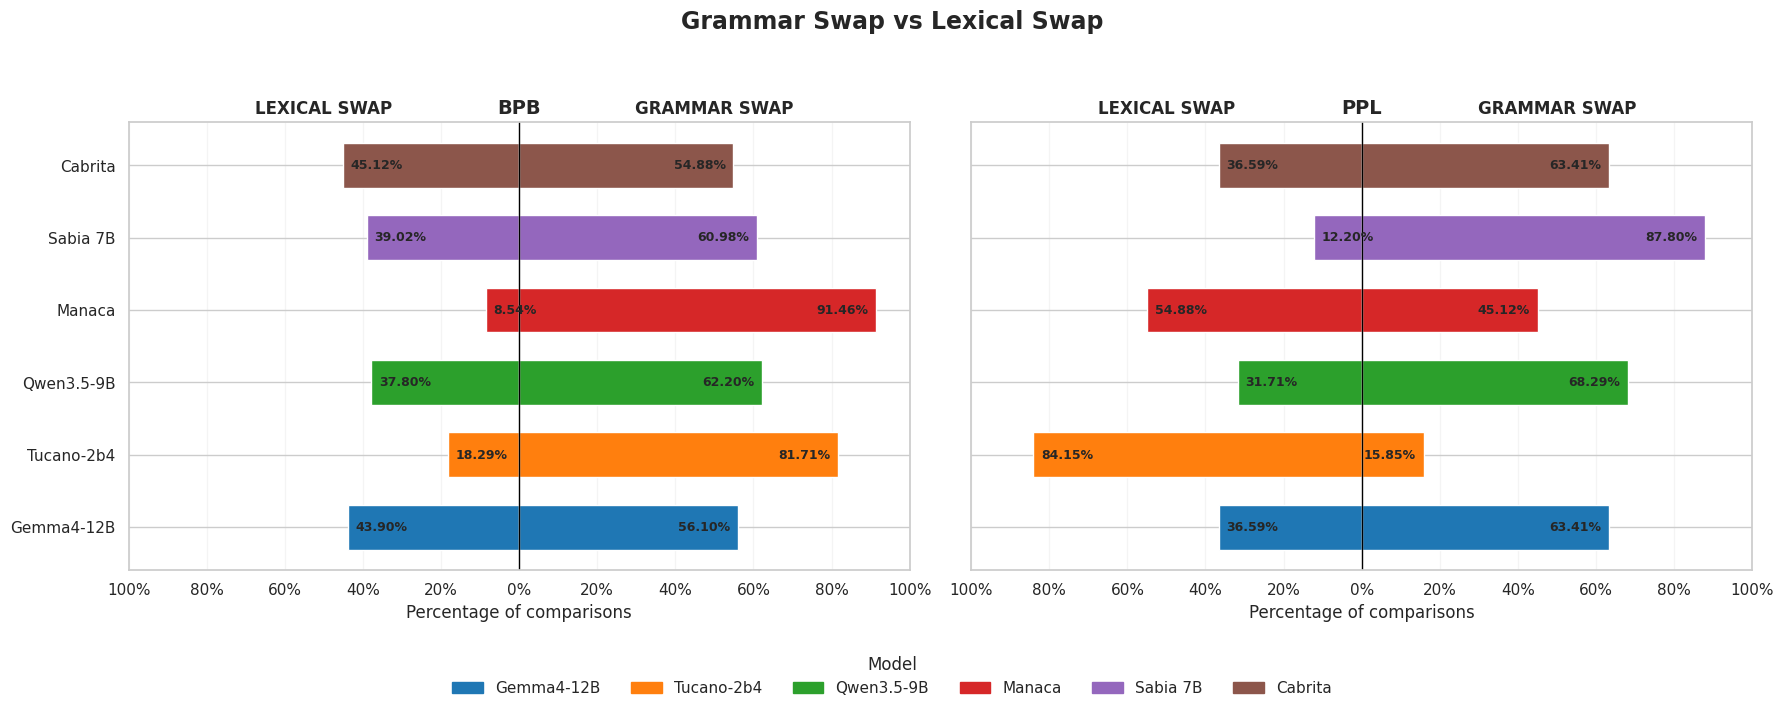

In [107]:
models = [
    "Gemma4-12B",
    "Tucano-2b4",
    "Qwen3.5-9B",
    "Manaca",
    "Sabia 7B",
    "Cabrita"
]

bpb_grammar = np.array([56.10, 81.71, 62.20, 91.46, 60.98, 54.88])
ppl_grammar = np.array([63.41, 15.85, 68.29, 45.12, 87.80, 63.41])

bpb_lexical = 100 - bpb_grammar
ppl_lexical = 100 - ppl_grammar

colors = plt.get_cmap("tab10").colors[:len(models)]


def plot_bidirectional(ax, grammar, lexical, metric):

    y = np.arange(len(models))

    for i, (g, l, color) in enumerate(zip(grammar, lexical, colors)):

        # Lexical on the left
        ax.barh(
            i,
            -l,
            color=color,
            height=0.62
        )

        # Grammar on the right
        ax.barh(
            i,
            g,
            color=color,
            height=0.62
        )

        # Lexical label
        ax.text(
            -l + 2,
            i,
            f"{l:.2f}%",
            va="center",
            ha="left",
            fontsize=9,
            fontweight="bold"
        )

        # Grammar label
        ax.text(
            g - 2,
            i,
            f"{g:.2f}%",
            va="center",
            ha="right",
            fontsize=9,
            fontweight="bold"
        )

    # Center line
    ax.axvline(0, color="black", linewidth=1)

    # Models
    ax.set_yticks(y)
    ax.set_yticklabels(models)

    ax.invert_yaxis()

    # Symmetric axis
    ax.set_xlim(-100, 100)

    ticks = np.arange(-100, 101, 20)

    ax.set_xticks(ticks)
    ax.set_xticklabels([
        f"{abs(t)}%" for t in ticks
    ])

    ax.set_title(
        metric,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Percentage of comparisons")

    # Left side
    ax.text(
        0.25,
        1.02,
        "LEXICAL SWAP",
        transform=ax.transAxes,
        ha="center",
        fontweight="bold"
    )

    # Right side
    ax.text(
        0.75,
        1.02,
        "GRAMMAR SWAP",
        transform=ax.transAxes,
        ha="center",
        fontweight="bold"
    )

    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)
# ======================================================
# CREATE BOTH CHARTS SIDE BY SIDE
# ======================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7),
    sharey=True
)

plot_bidirectional(
    axes[0],
    bpb_grammar,
    bpb_lexical,
    "BPB"
)

plot_bidirectional(
    axes[1],
    ppl_grammar,
    ppl_lexical,
    "PPL"
)

# Main title
fig.suptitle(
    "Grammar Swap vs Lexical Swap",
    fontsize=17,
    fontweight="bold"
)

# ------------------------------------------------------
# Shared model legend
# ------------------------------------------------------

legend_handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=colors[i]
    )
    for i in range(len(models))
]

fig.legend(legend_handles,models,title="Model",loc="lower center",bbox_to_anchor=(0.5, -0.02),ncol=len(models),frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 0.94])

plt.savefig(
    "bpb_ppl_bidirectional.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**O gráfico indica qual a procentagem de vezes em que um é MENOR que o outro**

- Quanto maior a preferência por um dos lados, menor é o valor da sua métrica
- O gráfico confirma a preferencia dos modelos pelo GRAMMAR SWAP
- A magnitude da preferencia muda consideravelmente
    - Nem sempre a magnitude reflete na discrepância de um para outro. Vide PPL do Sabiá
- Não há uma regra geral entre os modelos

# Perguntas para futuros testes

1. Por que os modelos focados no português têm métricas menores para o inglês do que para o português?
2. Observar:
    - GRAMMAR SWAP mostrou que os modelos tendem a preferir mais o texto em português do que a gramática
    - Mas isso é quebrado pelo fato do PB CORRUPTED ter explodido
    - Então o modelo tende a entender, sim, um pouco da gramatica, mas quanto?
3. O quanto o tamanho dos modelos influencia nesses resultados?